##**2.2 파이토치 기초 문법**

###**2.2.1 텐서 다루기**

[ 텐서 생성 및 변환 ]

In [1]:
import torch
print(torch.tensor([[1,2],[3,4]])) # 2차원 형태의 텐서 생성
print(torch.tensor([[1,2],[3,4]], device="cuda:0")) # GPU에 텐서 생성
print(torch.tensor([[1,2],[3,4]], dtype=torch.float64)) # dtype을 이용하여 텐서 생성

tensor([[1, 2],
        [3, 4]])
tensor([[1, 2],
        [3, 4]], device='cuda:0')
tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)


In [2]:
temp = torch.tensor([[1,2],[3,4]])
print(temp.numpy()) # 텐서를 ndarray로 변환

temp = torch.tensor([[1,2],[3,4]], device="cuda:0")
print(temp.to("cpu").numpy()) # GPU상의 텐서를 CPU의 텐서로 변환한 후 ndarray로 변환

[[1 2]
 [3 4]]
[[1 2]
 [3 4]]


[ 텐서의 인덱스 조작 ]

In [3]:
temp = torch.FloatTensor([1,2,3,4,5,6,7]) # 파이토치로 1차원 벡터 생성
print(temp[0], temp[1], temp[-1]) # 인덱스로 접근
print('--------------------------------')
print(temp[2:5], temp[4:-1]) # 슬라이스로 접근

tensor(1.) tensor(2.) tensor(7.)
--------------------------------
tensor([3., 4., 5.]) tensor([5., 6.])


[ 텐서 연산 및 차원 조작 ]

In [4]:
v = torch.tensor([1,2,3]) # 길이가 3인 벡터 생성
w = torch.tensor([3,4,6])
print(w - v) # 길이가 같은 벡터 간 뺄셈 연산

tensor([2, 2, 3])


In [5]:
temp = torch.tensor([[1,2],[3,4]]) # 2*2 행렬 생성

print(temp.shape)
print('---------------------')
print(temp.view(4,1)) # 2*2 행렬을 4*1로 변형
print('---------------------')
print(temp.view(-1)) # 2*2 행렬을 1차원 벡터로 변형
print('---------------------')
print(temp.view(1,-1)) # 2*2 행렬이 1*4가 되어 변형
print('---------------------')
print(temp.view(-1,1)) # 2*2 행렬이 4*1가 되어 변형

torch.Size([2, 2])
---------------------
tensor([[1],
        [2],
        [3],
        [4]])
---------------------
tensor([1, 2, 3, 4])
---------------------
tensor([[1, 2, 3, 4]])
---------------------
tensor([[1],
        [2],
        [3],
        [4]])


* -1은 (1, ?)와 같은 의미로 다른 차원으로부터 해당 값을 유추하겠다는 것
* temp의 원소 개수(2*2=4)를 유지한 채 (1,?)의 형태를 만족해야 하므로 (1,4)가 됨


###**2.2.2 데이터 준비**

[ 파이토치에서 제공하는 데이터셋 사용 ]

In [1]:
!pip install requests

In [3]:
import torchvision.transforms as transforms
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (1.0,))
]) # 평균이 0.5, 표준편차가 1.0이 되도록 데이터 분포(normalize)를 조정

from torchvision.datasets import MNIST
import requests
download_root = '/content/drive/MyDrive/Euron9_DL/MNIST_DATASET'

train_dataset = MNIST(download_root, transform=mnist_transform, train=True,
                      download=True) #훈련 데이터셋
valid_dataset = MNIST(download_root, transform=mnist_transform, train=False,
                      download=True) #검증 데이터셋
test_dataset = MNIST(download_root, transform=mnist_transform, train=False,
                      download=True) #테스트 데이터셋

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.52MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.7MB/s]


###**2.2.3 모델 정의**

[ 단순 신경망을 정의하는 방법 ]

In [ ]:
model = nn.Linear(in_features=1, out_features=1, bias=True)

[ nn.Module()을 상속하여 정의하는 방법 ]

In [ ]:
class MLP(Module):
  def __init__(self, inputs):
    super(MLP, self).__init__()
    self.layer=Linear(inputs,1) #계층 정의
    self.activation = Sigmoid() #활성화 함수 정의

  def forward(self, X):
    X = self.layer(X)
    X = self.activation(X)
    return X

[ Sequential 신경망을 정의하는 방법 ]

In [3]:
import torch.nn as nn
class MLP(nn.Module):
  def __init__(self):
    super(MLP, self).__init__()
    self.layer1 = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=64, kernel_size=5),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2)
    )
    self.layer2 = nn.Sequential(
        nn.Conv2d(in_channels=64, out_channels=30, kernel_size=5),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2)
    )
    self.layer3 = nn.Sequential(
        nn.Linear(in_features=30*5*5, out_features=10, bias=True),
        nn.ReLU(inplace=True)
    )
    def forward(self, x):
      x = self.layer1(x)
      x = self.layer2(x)
      x = x.view(x.shape[0], -1)
      x = self.layer3(x)
      return x
model = MLP() #모델에 대한 객체 생성

print("Printing children\n-----------------------------")
print(list(model.children()))
print('\n\nPrinting Modules\n-----------------------------')
print(list(model.modules()))

Printing children
-----------------------------
[Sequential(
  (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1))
  (1): ReLU(inplace=True)
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
), Sequential(
  (0): Conv2d(64, 30, kernel_size=(5, 5), stride=(1, 1))
  (1): ReLU(inplace=True)
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
), Sequential(
  (0): Linear(in_features=750, out_features=10, bias=True)
  (1): ReLU(inplace=True)
)]


Printing Modules
-----------------------------
[MLP(
  (layer1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(64, 30, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Linear(

[ 함수로 신경망을 정의하는 방법 ]

In [5]:
def MLP(in_features=1, hidden_features=20, out_features=1):
  hidden = nn.Linear(in_features=in_features, out_features=hidden_features,
                     bias=True)
  activation = nn.ReLU()
  output = nn.Linear(in_features=hidden_features, out_features=out_features,
                     bias=True)
  net = nn.Sequential(hidden, activation, output)
  return net

###**2.2.4 모델의 파라미터 정의**

In [ ]:
# 모델의 파라미터 정의 예시 코드
from torch.optim import optimizer
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(),lr=0.01, momentum=0.9)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer=torch.optimizer,
                                              lr_lambda=lambda epoch:0.95 ** epoch)
for epoch in range(1, 100+1): #에포크 수만큼 데이터를 반복하여 처리
  for x,y in dataloader: #배치 크기만큼 데이터를 가져와서 학습 진행
    optimizer.zero_grad()
loss_fn(model(x), y).backward()
optimizer.step()
scheduler.step()

###**2.2.5 모델 훈련**

In [ ]:
#모델 훈련 예시 코드
for epoch in range(100):
  yhat = model(x_train)
  loss = criterion(yhat, y_train)
  optimizer.zero_grad() # 오차가 중첩적으로 쌓이지 않도록 초기화
  loss.backward()
  optimizer.step()

###**2.2.6 모델 평가**

In [6]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 12.1 MB/s eta 0:00:00


In [ ]:
#함수 이용 모델 평가 코드(예시)
import torch
import torchmetrics

preds = torch.randn(10,5).softmax(dim=1)
target = torch.randint(5,(10,))

acc = torchmetrics.functional.accuracy(preds, target) # 모델 평가를 위해 torchmetrics.functional.accuracy이용

In [ ]:
#모듈 이용 모델 평가 코드(예시)
import torch
import torchmetrics
metrics = torchmetrics.Accuracy() #모델 평가(정확도) 초기화

n_batches = 10
for i in range(n_batches):
  preds = torch.randn(10,5).softmax(dim=-1)
  target = torch.randint(5,(10,))

  acc = metrics(preds, target)
  print(f"Accuracy on batch:{i}:{acc}") #현재 배치에서 모델 평가(정확도)

acc = metrics.compute()
print(f"Accuracy on all data: {acc}") #모든 배치에서 모델 평가 (정확도)

###**2.2.7 훈련 과정 모니터링**

In [7]:
!pip install tensorboard

In [ ]:
#텐서 보드 작성 코드(예시)
import torch
from torch.utils.tensorboard import SummaryWriter
writer= SummaryWriter("") #모니터링에 필요한 값들이 저장될 위치

for epoch in range(num_epochs):
  model.train() #학습 모드로 전환(dropout=True)
  batch_loss =0.0

  for i, (x,y) in enumerate(dataloader):
    x,y = x.to(device).float(), y.to(device).float()
    outputs = model(x)
    loss = criterion(outputs, y)
    writer.add_scalar("Loss", loss, epoch) #스칼라 값(오차)를 기록
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  writer.close() #SummaryWriter가 더이상 필요치 않으면 close()메서드 호출

In [ ]:
#텐서 보드 작성 코드(예시2-model.eval()사용)
model.eval() #검증 모드로 전환(dropout=False)
with torch.no_grad():
  valid_loss= 0

  for x,y in valid_dataloader:
    outputs = model(x)
    loss = F.cross_entropy(outputs, y.long().squeeze())
    valid_loss += float(loss)
    y_hat += [outputs]

  valid_loss = valid_loss / len(valid_loader)

In [8]:
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn

##**2.4 파이토치 코드 맛보기**

In [2]:
!pip install --upgrade matplotlib --use-feature=2020-resolver
!pip install --upgrade seaborn --use-feature=2020-resolver
!pip install --upgrade scikit-learn --use-feature=2020-resolver


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

option --use-feature: invalid choice: '2020-resolver' (choose from 'fast-deps', 'truststore', 'no-binary-enable-wheel-cache')

Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

option --use-feature: invalid choice: '2020-resolver' (choose from 'fast-deps', 'truststore', 'no-binary-enable-wheel-cache')

Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [opti

- 특성 확인
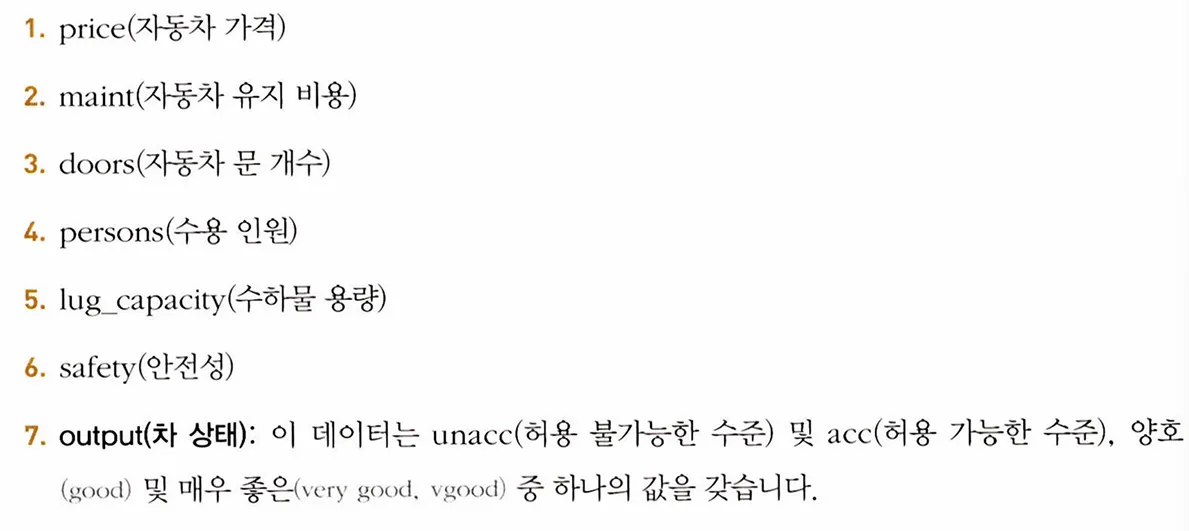

In [4]:
#2-1. 필요한 라이브러리 호출
import torch
import torch.nn as nn
import numpy as np #벡터 및 행렬 연산에서 매우 편리한 기능을 제공하는 파이썬 라이브러리 패키지
import pandas as pd #데이터 처리를 위해 널리 사용되는 파이썬 라이브러리 패키지
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
#2-2. 데이터 호출
dataset = pd.read_csv('/content/drive/MyDrive/Euron9_DL/car_evaluation.csv')
dataset.head()

,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


<Axes: ylabel='count'>

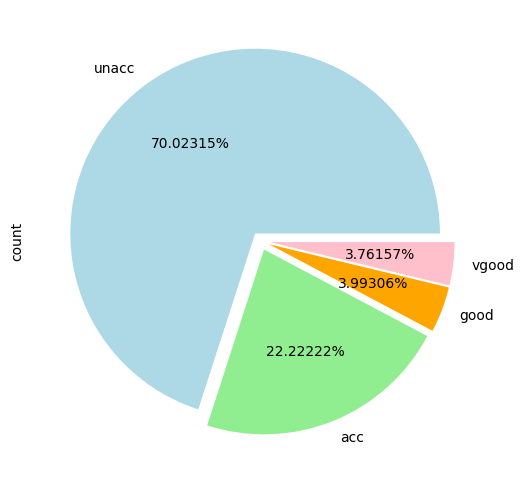

In [7]:
#2-3. 예제 데이터셋 분포
fig_size =plt.rcParams["figure.figsize"]
fig_size[0] = 8
fig_size[1] = 6
plt.rcParams["figure.figsize"] = fig_size
dataset.output.value_counts().plot(kind='pie',autopct='%0.05f%%',
colors=['lightblue','lightgreen','orange','pink'], explode=(0.05,0.05,0.05,0.05))

=> 약 70%가 unacc로, 양호한 상태의 자동차 비율이 매우 낮음

- DL은 통계 알고리즘을 기반 -> 단어를 숫자(텐서)로 변환해야함
  - 예제에서는 모두 범주형 데이터

In [34]:
#2-4. 데이터를 범주형 타입으로 변환
categorical_columns=['price','maint','doors','persons','lug_capacity','safety'] #예제 데이터셋 칼럼 목록

for category in categorical_columns:
  dataset[category]=dataset[category].astype('category') #astype()메서드 이용하여 데이터를 범주형으로 변환

price = dataset['price'].cat.codes.values #1
maint = dataset['maint'].cat.codes.values
doors = dataset['doors'].cat.codes.values
persons = dataset['persons'].cat.codes.values
lug_capacity = dataset['lug_capacity'].cat.codes.values
safety = dataset['safety'].cat.codes.values

categorical_data = np.stack([price, maint, doors, persons, lug_capacity, safety],1) #2
categorical_data[:10] #합친 넘파이 배열 중 열 개의 행 출력


array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

- #1 : 범주형 데이터를 텐서로 변환하기 위해 다음과 같은 절차 필요

  `범주형 데이터 -> dataset[category] -> 넘파이배열(NumPy array) -> 텐서(Tensor)`

  => 넘파이 배열을 통해서 텐서 생성

  - cat.codes : 범주형 데이터(단어)->숫자(넘파이 배열)로 변환하기 위해 사용
    
    단, 어떤 클래스가 어떤 숫자로 매핑 돼있는지 확인이 어려움

- #2. np.stack은 두 개 이상의 넘파이 객체를 합칠 때 사용

[ np.stack과 np.concatenate ]

공통점 : 넘파이 객체 합칠 때 사용

차이점 : 차원의 유지 여부

- np.concatenate : 선택한 축을 기준으로 두 개 배열 연결
  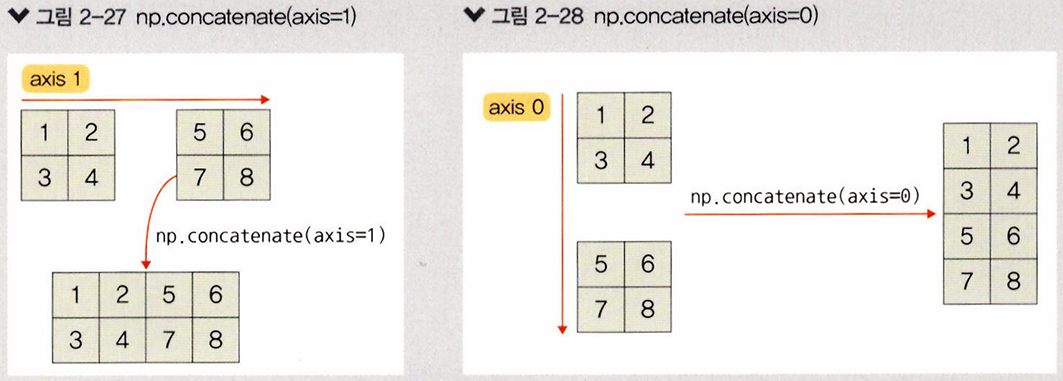

  - np.stack : 배열들을 새로운 축으로 합침
    - 1차원 배열들을 합쳐서 2차원 배열
    - 2차원 배열 여러 개를 합쳐 3차원 배열

    **반드시 두 배열의 차원이 동일해야 함**

    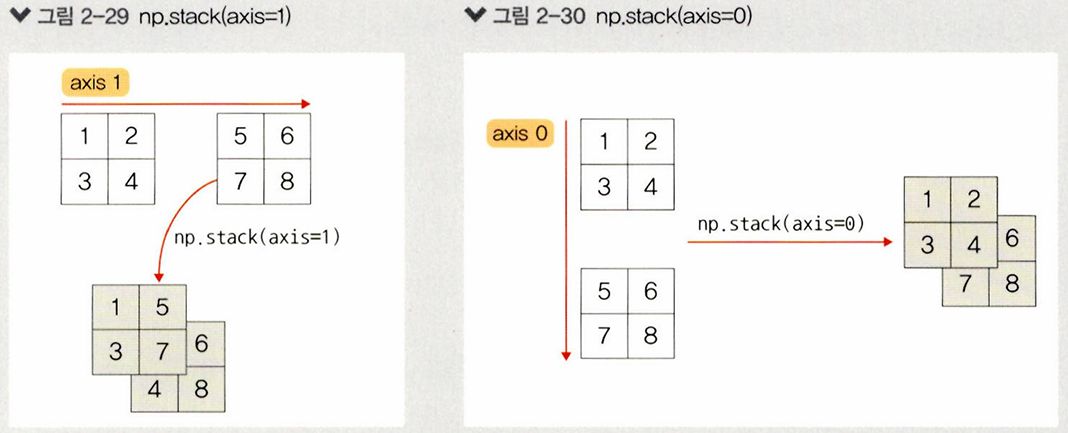

In [35]:
#2-5. 배열을 텐서로 변환
categorical_data = torch.tensor(categorical_data, dtype=torch.int64)
categorical_data[:10]

tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

In [36]:
#2-6. 레이블로 사용할 칼럼을 텐서로 변환
outputs = pd.get_dummies(dataset.output)
outputs = outputs.values
outputs = torch.tensor(outputs).flatten() #1차원 텐서로 변환

print(categorical_data.shape)
print(outputs.shape)

torch.Size([1728, 6])
torch.Size([6912])


- get_dummies : 가변수로 만드는 함수
  
  => 문자를 숫자(0,1)로 바꿔준다는 의미

- ravel(), reshape(), flatten(): 텐서의 차원을 바꿀 때 사용

[ 워드 임베딩 ]

  유사한 단어끼리 유사하게 인코딩되도록 표현하는 방법
  - 높은 차원의 임베딩일수록 단어 간의 세부적인 관계를 잘 파악 가능
  - 단일 숫자로 변환된 넘파이 배열을 N차원으로 변경하여 사용
  - 배열을 N차원으로 변환하기 위해 먼저 모든 범주형 칼럼에 대한 임베딩 크기(벡터 차원)를 정의
    - 칼럼의 고유 값 수를 2로 나누는 것을 많이 사용

In [37]:
#2-7. 범주형 칼럼을 N차원으로 변환
categorical_column_sizes = [len(dataset[column].cat.categories) for column in categorical_columns]
categorical_embedding_sizes = [(col_size, min(50, (col_size+1)//2)) for col_size in categorical_column_sizes]
print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


In [38]:
#2-8. 데이터셋 분리
total_records = 1728
test_records = int(total_records*.2) #전체 데이터 중 20%를 테스트 용도로 사용

categorical_train_data = categorical_data[:total_records-test_records]
categorical_test_data = categorical_data[total_records - test_records:total_records]
train_outputs = outputs[:total_records - test_records]
test_outputs = outputs[total_records - test_records:total_records]

In [39]:
#2-9. 데이터셋 분리 확인
print(len(categorical_train_data))
print(len(train_outputs))
print(len(categorical_test_data))
print(len(test_outputs))

1383
1383
345
345


In [48]:
#2-10. 모델의 네트워크 생성
class Model(nn.Module): #1
  def __init__(self, embedding_size, output_size, layers, p=0.4): #2
    super().__init__() #3
    self.all_embeddings = nn.ModuleList([nn.Embedding(ni,nf) for ni,
                                         nf in embedding_size])
    self.embedding_dropout = nn.Dropout(p)

    all_layers =[] #4
    num_categorical_cols = sum((nf for ni, nf in embedding_size))
    input_size = num_categorical_cols #입력층의 크기를 찾기 위해 범주형 칼럼 개수를 input_size변수에 저장

    for i in layers :
      all_layers.append(nn.Linear(input_size, i))
      all_layers.append(nn.ReLU(inplace=True))
      all_layers.append(nn.BatchNorm1d(i))
      all_layers.append(nn.Dropout(p))
      input_size = i

    all_layers.append(nn.Linear(layers[-1], output_size))
    self.layers = nn.Sequential(*all_layers) #신경망의 모든 계층이 순차적으로 실행되도록
                                             #모든 계층에 대한 목록(all_layers)을 nn.Sequential클래스로 전달
  def forward(self, x_categorical): #5
    embeddings =[]
    for i, e in enumerate(self.all_embeddings):
      embeddings.append(e(x_categorical[:,i]))
    x=torch.cat(embeddings,1) #넘파이의 cocatenate와 같지만 대상이 텐서
    x=self.embedding_dropout(x)
    x=self.layers(x)
    return x

- #1 : 클래스 형태로 구현되는 모델은 nn.Module 상속을 받음
- #2 : __ init__(): 모델에서 사용될 파라미터와 신경망 초기화를 위한 용도. 객체 생성시 자동 호출

- #3 : super().__init __()은 부모 클래스에 접근할 때 사용하며 super는 self를 사용하지 않는 것에 주의
- #4 : 모델의 네트워크 계층을 구축하기 위해 for문을 이용하여 각 계측을 all_layers목록에 추가
  - Linear: 선형계층은 입력 데이터에 선형 변환을 진행한 결과
  - ReLU: 활성화 함수로 사용
  - BatchNorm1d : 배치 정규화 용도로 사용
  - Dropout: 과적합 방지에 사용

- #5 : forward() : 학습 데이터를 입력 받아 연산 진행. 모델 객체를 데이터와 함께 호출하며 자동 실행

📚__init __() 매개변수

  `def __init __ (self, embedding_size, output_size, layers, p=0.4)`

1. self : 첫 번째 파라미터로 지정되어야 하며 자기 자신을 의미
  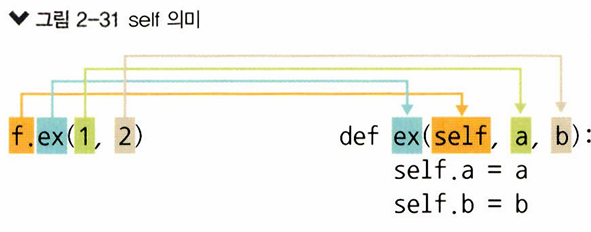
2. embedding_size: 범주형 칼럼의 임베딩
3. output_size : 출력층의 크기
4. layers : 모든 계층에 대한 목록
5. p : 드롭아웃(기본 값:0.5)


In [49]:
#2-11. Model 클래스의 객체 생성
model = Model(categorical_embedding_sizes, 4, [200,100,50], p=0.4)
print(model)

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


In [50]:
#2-12. 모델의 파라미터 정의
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [51]:
#2-13. CPU/GPU 사용 지정
if torch.cuda.is_available():
  device = torch.device('cuda') #GPU가 있다면 GPU 사용
else:
  device = torch.device('cpu') #GPU가 없다면 CPU사용

In [56]:
#2-14. 모델 학습
epochs = 500
aggregated_losses = []
train_outputs = train_outputs.to(device=device, dtype=torch.int64)

for i in range(epochs): #for문은 500회 반복되며, 각 반복마다 손실 함수가 오차를 계산
  i += 1
  y_pred = model(categorical_train_data).to(device)
  single_loss = loss_function(y_pred, train_outputs)
  aggregated_losses.append(single_loss)

  if i%25 ==1:
    print(f'epoch: {i:3} loss: {single_loss.item(): 10.8f}')

    optimizer.zero_grad()
    single_loss.backward() #가중치를 업데이트하기 위해 손실함수의 backward()메서드 호출
    optimizer.step() #옵티마이저 함수의 step() 메서드를 이용하여 기울기 업데이트

print(f'epoch: {i:3} loss: {single_loss.item():10.10f}') #오차가 25에포크마다 출력

epoch:   1 loss:  1.39130771
epoch:  26 loss:  1.36750913
epoch:  51 loss:  1.35262585
epoch:  76 loss:  1.36602318
epoch: 101 loss:  1.36504889
epoch: 126 loss:  1.35770833
epoch: 151 loss:  1.35752201
epoch: 176 loss:  1.36418927
epoch: 201 loss:  1.33434522
epoch: 226 loss:  1.34344649
epoch: 251 loss:  1.33749199
epoch: 276 loss:  1.34586632
epoch: 301 loss:  1.33025372
epoch: 326 loss:  1.34382629
epoch: 351 loss:  1.31739759
epoch: 376 loss:  1.35356104
epoch: 401 loss:  1.33747387
epoch: 426 loss:  1.33458161
epoch: 451 loss:  1.33061862
epoch: 476 loss:  1.32205367
epoch: 500 loss: 1.3023816347


In [57]:
#2-15. 테스트 데이터셋으로 모델 예측
test_outputs = test_outputs.to(device=device, dtype=torch.int64)
with torch.no_grad():
  y_val = model(categorical_test_data)
  loss = loss_function(y_val, test_outputs)
print(f'Loss: {loss:.8f}')

Loss: 1.27801454


In [58]:
#2-16. 모델의 예측 확인
print(y_val[:5])

tensor([[ 0.0913,  0.1729,  0.3187,  0.0670],
        [ 0.1397, -0.0641, -0.8685, -0.3657],
        [ 2.0291,  0.9844, -1.5401, -0.0521],
        [ 1.0339, -1.0165,  0.3127,  0.4977],
        [ 0.4367, -0.3235, -0.0848, -0.2678]])


In [59]:
#2-17. 가장 큰 값을 갖는 인덱스 확인
y_val = np.argmax(y_val, axis=1)
print(y_val[:5])

tensor([2, 0, 0, 0, 0])


In [60]:
#2-18. 테스트 데이터셋을 이용한 정확도 확인
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(test_outputs,y_val))
print(classification_report(test_outputs,y_val))
print(accuracy_score(test_outputs, y_val))

[[139  62  38  20]
 [ 25  29  15  17]
 [  0   0   0   0]
 [  0   0   0   0]]
              precision    recall  f1-score   support

           0       0.85      0.54      0.66       259
           1       0.32      0.34      0.33        86
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0

    accuracy                           0.49       345
   macro avg       0.29      0.22      0.25       345
weighted avg       0.72      0.49      0.58       345

0.48695652173913045


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


###딥러닝 성능 평가 지표

[ 용어 ]
- True Positive : 모델이 1이라고 예측, 실제 값도 1
- True Negative : 모델이 0이라고 예측, 실제 값도 0
- False Positive : 모델이 1이라고 예측, 실제 값은 0 (Type I 오류)
- False Negative : 모델이 0이라고 예측, 실제 값 1 (Type II 오류)

[ 정확도 ]
- 전체 예측 건수에서 정답을 맞힌 건수의 비율
- 맞힌 정답이 긍정/부정 상관X
- (True Positive + True Negative) / ( True Positive + True Negative + False Positive + False Negative)


[ 재현율 ]
- 실제로 정답이 1이라고 할 대 모델도 1로 예측한 비율
- 처음부터 데이터가 1일 확률이 적을 때 사용하면 좋음
- (True Positive ) / (True Positive + False Negative)

[ 정밀도 ]
- 모델이 1이라고 예측한 것 중에 실제로 정답이 1인 비율
- (True Positive) / (True Positive + False Positive)

[ F1-스코어 ]

*일반적으로 정밀도와 재현율은 트레이드오프 관계 : 정밀도가 높으면 재현율이 낮고, 재현율이 높으면 정밀도가 낮음

=> 이를 해결하기 위해 조화 평균을 이용한 것이 F1-스코어 평가

- 2 * (정밀도 * 재현율 ) /(정밀도 + 재현율 )
